# BESTEST LBNL-style report — Case 900

Native Python ISO results may be used for formal ASHRAE annual-energy assessment. `modelica_solar` is a controlled-forcing comparison and is not formal pass/fail.

In [1]:
from pathlib import Path
import subprocess, sys
import matplotlib.pyplot as plt
import pandas as pd

ISO_MODE = 'modelica_solar'  # accepted: 'modelica_solar', 'native'
cwd = Path.cwd().resolve()
root = next((p for p in (cwd, *cwd.parents) if (p / 'scripts/bestest_iso_run_case900_validation.py').is_file()), None)
if root is None:
    candidate = cwd / '2__validation/_BESTEST'
    if not (candidate / 'scripts/bestest_iso_run_case900_validation.py').is_file():
        raise FileNotFoundError('Open from _BESTEST or _development.')
    root = candidate
sys.path.insert(0, str(root / 'scripts'))
from bestest_iso_reporting import (MODELICA_LABEL, annual_energy_table, daily_slice, peak_table, selected_hourly, selected_iso_mode)
subprocess.run([sys.executable, 'scripts/bestest_iso_run_case900_validation.py'], cwd=root, check=True)
reference = root / '_ref/BESTEST_LBNL_all_cases_reference.md'
case = '900'
result_dir = root / 'results' / '1_iso' / f'case{case}'
metrics = pd.read_csv(result_dir / f'case{case}_metrics.csv')
hourly = pd.read_csv(result_dir / f'case{case}_feb1_load_profile.csv')
iso_run_mode, ISO_LABEL = selected_iso_mode(ISO_MODE)
def annual_range_plot(table, title):
    row = table.iloc[0]
    values = row.drop(labels=['Case', 'ASHRAE lower', 'ASHRAE upper', 'Python range status']).astype(float)
    fig, ax = plt.subplots(figsize=(9, 3.4))
    ax.bar(values.index, values.values, color='#4C78A8')
    ax.axhline(row['ASHRAE lower'], color='#555555', linestyle='--', label='ASHRAE lower')
    ax.axhline(row['ASHRAE upper'], color='#555555', linestyle='--', label='ASHRAE upper')
    ax.set(ylim=(0, 1.2 * max(values.max(), row['ASHRAE upper'])), ylabel='MWh', title=title)
    ax.legend(); ax.grid(axis='y', alpha=.2); plt.xticks(rotation=45, ha='right'); fig.tight_layout(); plt.show()

## 1. Annual heating energy

Annual heating energy for the implemented conditioned case, in MWh.

,Case,ASHRAE lower,ASHRAE upper,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar,Python range status
0,900,1.04,2.28,1.726,1.379,1.591,1.664,1.585,1.814,1.832767,1.818536,PASS — diagnostic


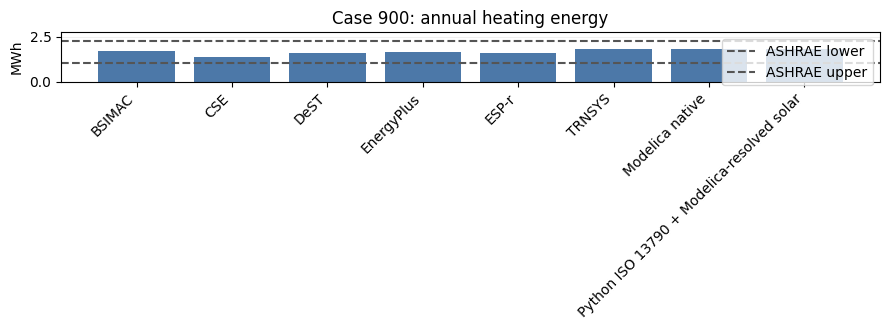

In [2]:
heating = annual_energy_table(metrics, reference, case, 'annual_heating_energy', ISO_MODE)
display(heating)
annual_range_plot(heating, f'Case {case}: annual heating energy')

## 2. Annual cooling energy

Annual cooling energy for the implemented conditioned case, in MWh.

,Case,ASHRAE lower,ASHRAE upper,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar,Python range status
0,900,2.35,2.6,2.714,2.464,2.383,2.489,2.488,2.267,2.28441,2.284475,FAIL — diagnostic


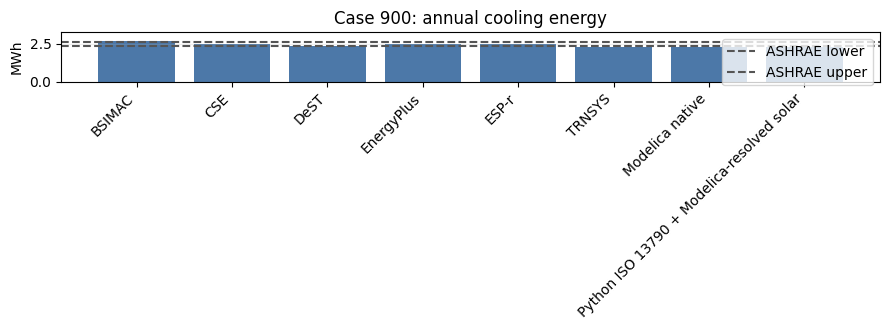

In [3]:
cooling = annual_energy_table(metrics, reference, case, 'annual_cooling_energy', ISO_MODE)
display(cooling)
annual_range_plot(cooling, f'Case {case}: annual cooling energy')

## 3. Peak heating load

Peak heating load and completed-hour occurrence time, in kW.

In [4]:
display(peak_table(metrics, reference, case, 'peak_heating_load', ISO_MODE))

,Case,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar
0,900,2.551 (08-Feb:24),2.443 (09-Feb:6),2.453 (09-Feb:5),2.687 (09-Feb:6),2.633 (09-Feb:7),2.778 (09-Feb:7),2.640 (09-Feb:06),2.647 (09-Feb:06)


## 4. Peak cooling load

Peak cooling load and completed-hour occurrence time, in kW.

In [5]:
display(peak_table(metrics, reference, case, 'peak_cooling_load', ISO_MODE))

,Case,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar
0,900,3.039 (01-Oct:15),3.376 (01-Oct:14),2.556 (11-Sep:14),3.040 (01-Oct:14),2.896 (12-Oct:15),2.940 (01-Oct:14),2.365 (01-Oct:15),2.373 (01-Oct:15)


## 5. Daily load profile

Case 900 heating and cooling hourly averages on 1 February, plotted at completed hours 1–24. Completed hour 1 represents 00:00–01:00 and hour 24 represents 23:00–24:00; neither track is shifted.

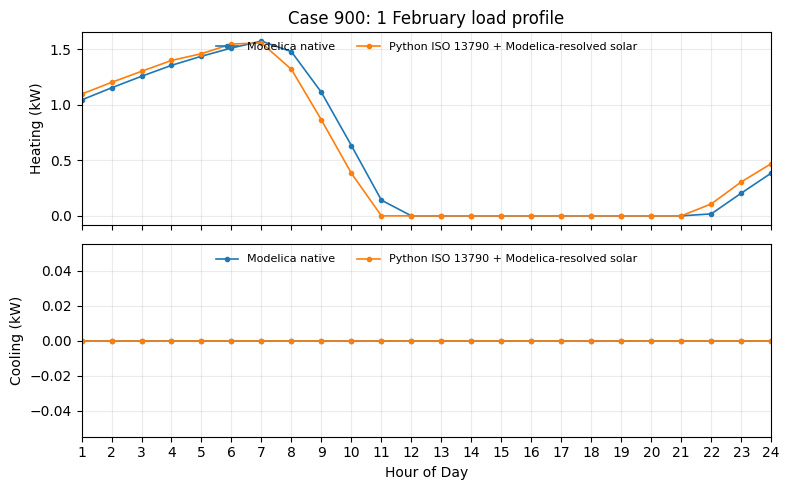

In [6]:
profile = daily_slice(selected_hourly(hourly, ISO_MODE), 2, 1)
profile['run'] = profile.implementation.map({'modelica': MODELICA_LABEL, 'iso13790': ISO_LABEL})
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
for run, frame in profile.groupby('run'):
    frame = frame.sort_values('hour')
    axes[0].plot(frame.hour, frame.heating_load_W / 1000, marker='o', markersize=3, linewidth=1.2, label=run)
    axes[1].plot(frame.hour, frame.cooling_load_W / 1000, marker='o', markersize=3, linewidth=1.2, label=run)
axes[0].set(ylabel='Heating (kW)', title='Case 900: 1 February load profile')
axes[1].set(xlabel='Hour of Day', ylabel='Cooling (kW)', xlim=(1, 24), xticks=range(1, 25))
for axis in axes: axis.grid(alpha=.25); axis.legend(loc='upper center', ncol=2, fontsize=8, frameon=False)
fig.tight_layout(); plt.show()

## Summary

Current Case 900 annual-energy record; the main report uses the selected `ISO_MODE`.

In [7]:
summary = metrics[metrics.metric.isin(['annual_heating_energy', 'annual_cooling_energy'])].copy()
summary['Run'] = summary.apply(lambda x: MODELICA_LABEL if x.implementation == 'modelica' else ('Native ISO' if x.run_mode == 'native' else 'ISO + Modelica solar'), axis=1)
energy = summary.pivot(index='Run', columns='metric', values='value').rename(columns={'annual_heating_energy': 'Heating (MWh)', 'annual_cooling_energy': 'Cooling (MWh)'}).reindex(['Native ISO', 'ISO + Modelica solar', MODELICA_LABEL])
formal = pd.read_csv(result_dir / f'case{case}_formal_ashrae_energy.csv')
bounds = formal.drop_duplicates('metric').set_index('metric')[['lower', 'upper']]
def annual_status(run, metric):
    value = energy.loc[run, 'Heating (MWh)' if metric == 'annual_heating_energy' else 'Cooling (MWh)']
    status = 'PASS' if bounds.loc[metric, 'lower'] <= value <= bounds.loc[metric, 'upper'] else 'FAIL'
    return f'{status}' if run == 'ISO + Modelica solar' else status
summary_table = pd.DataFrame([{
    'Run': run,
    'Heating (MWh)': energy.loc[run, 'Heating (MWh)'],
    'Heating range (MWh)': f"{bounds.loc['annual_heating_energy', 'lower']:.2f}–{bounds.loc['annual_heating_energy', 'upper']:.2f}",
    'Heating status': annual_status(run, 'annual_heating_energy'),
    'Cooling (MWh)': energy.loc[run, 'Cooling (MWh)'],
    'Cooling range (MWh)': f"{bounds.loc['annual_cooling_energy', 'lower']:.2f}–{bounds.loc['annual_cooling_energy', 'upper']:.2f}",
    'Cooling status': annual_status(run, 'annual_cooling_energy'),
} for run in energy.index])
display(summary_table)
print('Controlled-forcing ISO is close to Modelica; native ISO remains affected by the unresolved solar-preprocessing discrepancy. The main report uses ISO_MODE =', ISO_MODE)

,Run,Heating (MWh),Heating range (MWh),Heating status,Cooling (MWh),Cooling range (MWh),Cooling status
0,Native ISO,4.790196,1.04–2.28,FAIL,0.614339,2.35–2.60,FAIL
1,ISO + Modelica solar,1.818536,1.04–2.28,PASS,2.284475,2.35–2.60,FAIL
2,Modelica native,1.832767,1.04–2.28,PASS,2.284410,2.35–2.60,FAIL


Controlled-forcing ISO is close to Modelica; native ISO remains affected by the unresolved solar-preprocessing discrepancy. The main report uses ISO_MODE = modelica_solar
